# Building Classification Experiments

## Requirements

In [ ]:
%%writefile requirements.txt
torch
torchvision
matplotlib
numpy
pandas
tqdm
opencv-python
albumentations

Writing requirements.txt


In [ ]:
!pip install -r requirements.txt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 50.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 24.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 33.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 13.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 42.2 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling nvidia-nvjitlink-cu12-12.5.82:
      Successfully uninstalled nvidia-nvjitlin

## Imports

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

import sys
sys.path.append('/content/drive/MyDrive/thesis_code/classification')

Mounted at /content/drive


In [ ]:
import os
import pandas as pd
import torch
import cv2
import numpy as np
import matplotlib.pyplot as plt

from torch import nn
from torch import optim
from torch.optim import lr_scheduler

from scripts.loader import get_dataloaders
from scripts.transforms import get_default_transforms
from scripts.models import DamageNet, ResNetSiameseNetwork
from scripts.train import train_siamese_model, train_damagenet_model
from scripts.evaluation import (
    evaluate_siamese, evaluate_damagenet,
    analyze_model_errors_by_size, plot_error_rate_by_size_group,
    plot_error_gap_vs_size, plot_error_gap_distribution_by_size_group,
)

/usr/local/lib/python3.11/dist-packages/albumentations/__init__.py:28: UserWarning: A new version of Albumentations is available: '2.0.6' (you have '2.0.5'). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()


## Data Retrieval

In [ ]:
!unzip "/content/drive/MyDrive/thesis_code/classification/data/XViewClassificationMasks.zip" -d "/content"

Показано результат, скорочений до останніх рядків (5000).
  inflating: /content/data/val/post/hurricane-florence_00000408_b3b3a62c-b2a5-4667-959b-8c1e7df614fb.png  
  inflating: /content/data/val/post/palu-tsunami_00000066_25795725-85f1-4902-98a1-462b255740eb.png  
  inflating: /content/data/val/post/hurricane-harvey_00000440_0de13fac-4c42-474a-8b74-d9c792081f40.png  
 extracting: /content/data/val/post/hurricane-harvey_00000347_8a799243-9929-4a82-b958-2318615141aa.png  
  inflating: /content/data/val/post/hurricane-matthew_00000023_b6d73455-a8a9-44c7-a232-53850335a033.png  
  inflating: /content/data/val/post/hurricane-matthew_00000338_51f31d2c-19cc-43dc-80c2-e9ea1df9b0e7.png  
 extracting: /content/data/val/post/hurricane-harvey_00000361_9ca843fb-173a-425e-b445-994fa7654b70.png  
  inflating: /content/data/val/post/hurricane-harvey_00000361_163c877a-a42e-4f23-a27f-27dc1e7c8765.png  
 extracting: /content/data/val/post/hurricane-harvey_00000502_ffbddece-4052-4ccf-ae13-d3c1eaef7ebf.png

## Experiments

### ResNet34 Siamese

#### Dataset

In [ ]:
transform = get_default_transforms()

train_loader, val_loader, test_loader = get_dataloaders("data", dataset_type="disaster", transform=transform)

#### Classification

##### Training

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = ResNetSiameseNetwork(output_size=512, n_classes=4, freeze=True).to(device)

loss_fn = torch.nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

# Learning rate scheduler (optional)
scheduler = lr_scheduler.ReduceLROnPlateau(
            optimizer, factor=0.1, patience=10, min_lr=1e-5, verbose=True
        )

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet34_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet34_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet34-b627a593.pth" to /root/.cache/torch/hub/checkpoints/resnet34-b627a593.pth
100%|██████████| 83.3M/83.3M [00:00<00:00, 197MB/s]
/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(

In [ ]:
train_logs, val_logs = train_siamese_model(
    model, train_loader, val_loader, loss_fn, optimizer, lr_scheduler=scheduler, epochs=10, device=device, save_path="/content/drive/MyDrive/thesis_code/classification/models"
)


Epoch 1/1


Validation: 100%|██████████| 175/175 [00:23<00:00,  7.38it/s]

Train Loss: 0.9475, Precision: 0.6107, Recall: 0.6120, F1: 0.6110, Accuracy: 0.6120
Val Loss: 0.8422, Precision: 0.6688, Recall: 0.6682, F1: 0.6672, Accuracy: 0.6682


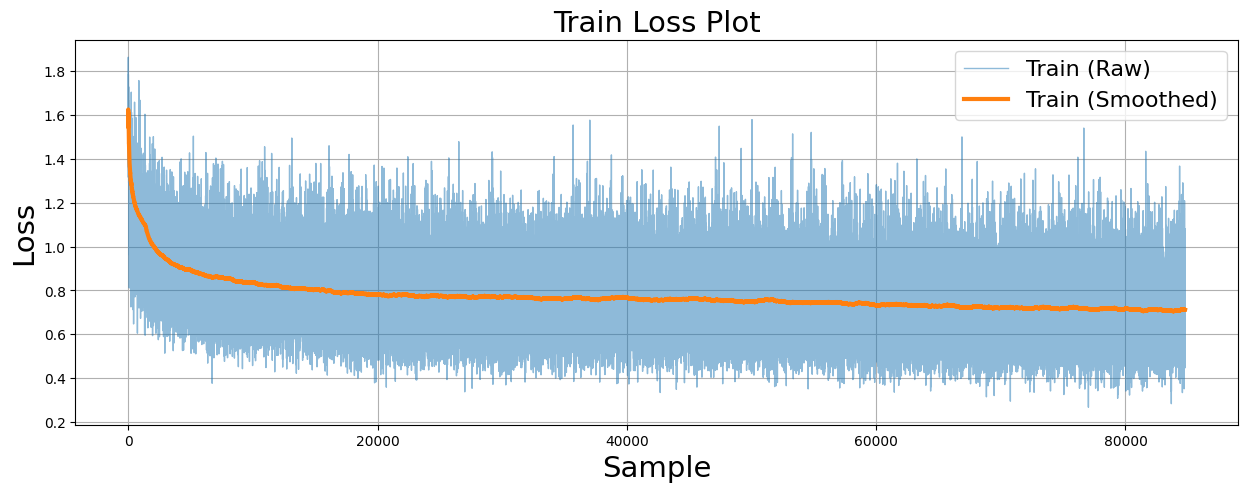

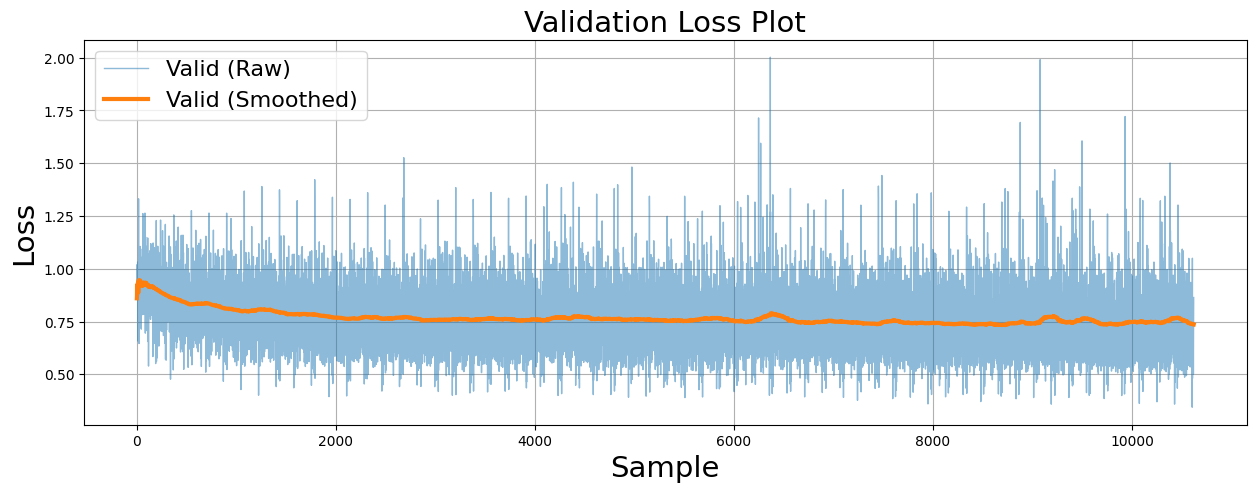

In [ ]:
train_series = pd.Series(train_logs)
val_series = pd.Series(val_logs)

# Compute rolling mean
train_smooth = train_series.rolling(window=1413, min_periods=1).mean()
val_smooth = val_series.rolling(window=177, min_periods=1).mean()

# Plot Train Loss
plt.figure(figsize=(15, 5))
plt.plot(train_logs, lw=1, alpha=0.5, label='Train (Raw)')
plt.plot(train_smooth, lw=3, label='Train (Smoothed)')
plt.xlabel('Sample', fontsize=21)
plt.ylabel('Loss', fontsize=21)
plt.title('Train Loss Plot', fontsize=21)
plt.legend(loc='best', fontsize=16)
plt.grid()
plt.show()

# Plot Validation Loss
plt.figure(figsize=(15, 5))
plt.plot(val_logs, lw=1, alpha=0.5, label='Valid (Raw)')
plt.plot(val_smooth, lw=3, label='Valid (Smoothed)')
plt.xlabel('Sample', fontsize=21)
plt.ylabel('Loss', fontsize=21)
plt.title('Validation Loss Plot', fontsize=21)
plt.legend(loc='best', fontsize=16)
plt.grid()
plt.show()

##### Evaluation

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = ResNetSiameseNetwork(output_size=512, n_classes=4, freeze=True).to(device)

loss_fn = torch.nn.CrossEntropyLoss()

checkpoint_path = "/content/drive/MyDrive/thesis_code/classification/models/model_ResNet34_60.pt"

# Load the checkpoint
checkpoint = torch.load(checkpoint_path, map_location=device)

# Restore the states
model.load_state_dict(checkpoint["model_state"])

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet34_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet34_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet34-b627a593.pth" to /root/.cache/torch/hub/checkpoints/resnet34-b627a593.pth
100%|██████████| 83.3M/83.3M [00:01<00:00, 72.5MB/s]


<All keys matched successfully>

Evaluating Siamese: 100%|██████████| 177/177 [00:25<00:00,  7.06it/s]



Siamese Evaluation (Classification):
  Loss:      0.6584
  Accuracy:  0.7429
  Precision: 0.7498
  Recall:    0.7452
  F1 Score:  0.7436
  MSE: 0.6615
  MAE: 0.3739


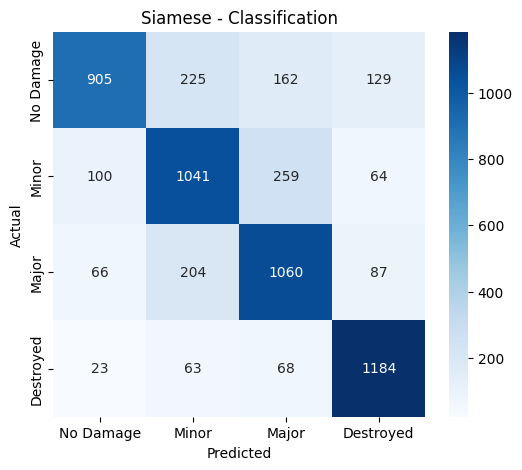

In [ ]:
metrics = evaluate_siamese(model, test_loader, "cuda")

#### Regression

##### Training

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

mode = 'regression'

model = ResNetSiameseNetwork(output_size=512, output_type=mode, freeze=True).to(device)

loss_fn = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

# Learning rate scheduler (optional)
scheduler = lr_scheduler.ReduceLROnPlateau(
            optimizer, factor=0.1, patience=10, min_lr=1e-5, verbose=True
        )

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet34_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet34_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


In [ ]:
train_logs, val_logs = train_siamese_model(
    model, train_loader, val_loader, loss_fn, optimizer, scheduler, epochs=20, device=device, mode=mode, save_path="/content/drive/MyDrive/thesis_code/classification/models"
)


Epoch 1/20


Validation: 100%|██████████| 175/175 [00:24<00:00,  7.18it/s]


Train Loss: 0.5928, Precision: 0.6257, Recall: 0.5103, F1: 0.5171, Accuracy: 0.5103
Val Loss: 0.5905, Precision: 0.6501, Recall: 0.5491, F1: 0.5531, Accuracy: 0.5491

Epoch 2/20


Validation: 100%|██████████| 175/175 [00:24<00:00,  7.11it/s]


Train Loss: 0.5896, Precision: 0.6252, Recall: 0.5105, F1: 0.5175, Accuracy: 0.5105
Val Loss: 0.5696, Precision: 0.6446, Recall: 0.5564, F1: 0.5622, Accuracy: 0.5564

Epoch 3/20


...

Train Loss: 0.5503, Precision: 0.6428, Recall: 0.5393, F1: 0.5476, Accuracy: 0.5393
Val Loss: 0.5768, Precision: 0.6730, Recall: 0.5754, F1: 0.5813, Accuracy: 0.5754

Epoch 19/20


Validation: 100%|██████████| 175/175 [00:24<00:00,  7.27it/s]


Train Loss: 0.5505, Precision: 0.6483, Recall: 0.5463, F1: 0.5541, Accuracy: 0.5463
Val Loss: 0.5587, Precision: 0.6703, Recall: 0.5586, F1: 0.5616, Accuracy: 0.5586

Epoch 20/20


Validation: 100%|██████████| 175/175 [00:23<00:00,  7.39it/s]


Train Loss: 0.5483, Precision: 0.6469, Recall: 0.5437, F1: 0.5520, Accuracy: 0.5437
Val Loss: 0.5603, Precision: 0.6649, Recall: 0.5729, F1: 0.5792, Accuracy: 0.5729


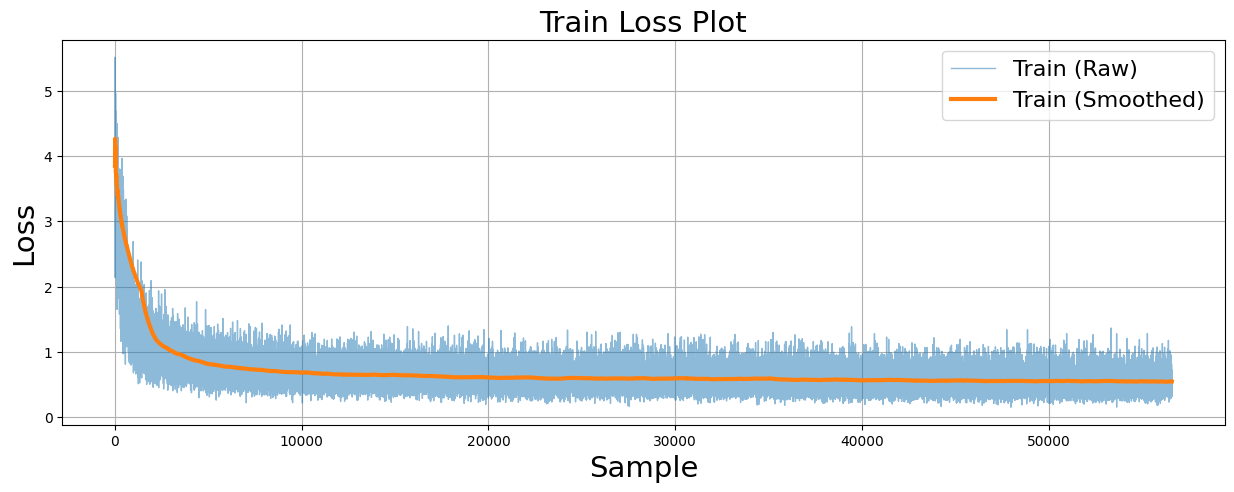

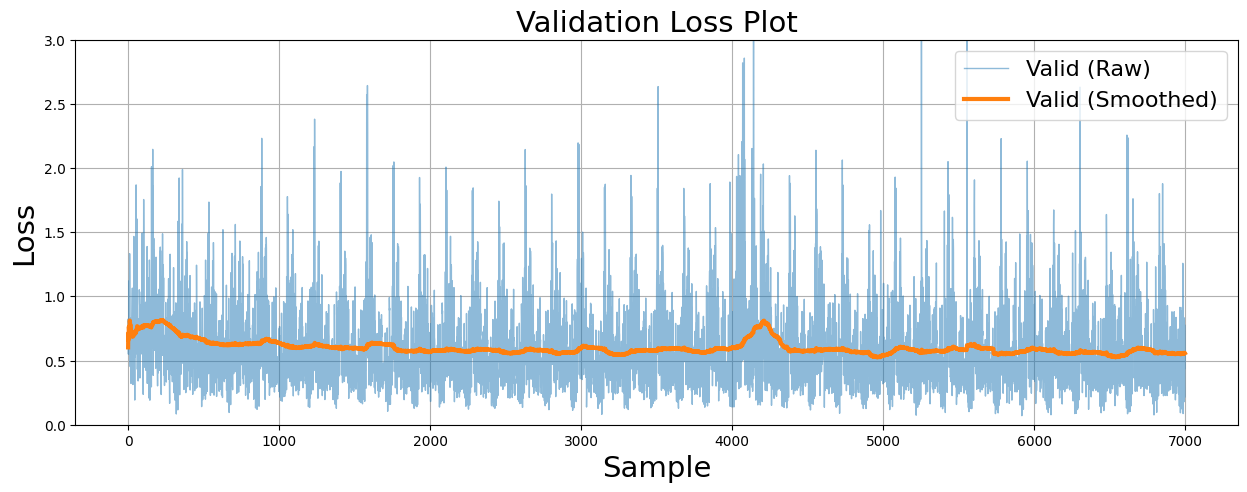

In [ ]:
train_series = pd.Series(train_logs)
val_series = pd.Series(val_logs)

# Compute rolling mean
train_smooth = train_series.rolling(window=1413, min_periods=1).mean()
val_smooth = val_series.rolling(window=177, min_periods=1).mean()

# Plot Train Loss
plt.figure(figsize=(15, 5))
plt.plot(train_logs, lw=1, alpha=0.5, label='Train (Raw)')
plt.plot(train_smooth, lw=3, label='Train (Smoothed)')
plt.xlabel('Sample', fontsize=21)
plt.ylabel('Loss', fontsize=21)
plt.title('Train Loss Plot', fontsize=21)
plt.legend(loc='best', fontsize=16)
plt.grid()
plt.show()

# Plot Validation Loss
plt.figure(figsize=(15, 5))
plt.plot(val_logs, lw=1, alpha=0.5, label='Valid (Raw)')
plt.plot(val_smooth, lw=3, label='Valid (Smoothed)')
plt.xlabel('Sample', fontsize=21)
plt.ylabel('Loss', fontsize=21)
plt.title('Validation Loss Plot', fontsize=21)
plt.legend(loc='best', fontsize=16)
plt.ylim(0, 3)
plt.grid()

##### Evaluation

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

mode = 'regression'

model = ResNetSiameseNetwork(output_size=512, output_type=mode, freeze=True).to(device)

checkpoint_path = "/content/drive/MyDrive/thesis_code/classification/models/model_SiameseResNet_regression_epoch40.pt"

# Load the checkpoint
checkpoint = torch.load(checkpoint_path, map_location=device)

# Restore the states
model.load_state_dict(checkpoint["model_state"])

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet34_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet34_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


<All keys matched successfully>

Evaluating Siamese:   0%|          | 0/177 [00:00<?, ?it/s]/usr/local/lib/python3.11/dist-packages/torch/nn/modules/loss.py:610: UserWarning: Using a target size (torch.Size([32])) that is different to the input size (torch.Size([32, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
Evaluating Siamese:  99%|█████████▉| 176/177 [00:23<00:00,  7.77it/s]/usr/local/lib/python3.11/dist-packages/torch/nn/modules/loss.py:610: UserWarning: Using a target size (torch.Size([8])) that is different to the input size (torch.Size([8, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
Evaluating Siamese: 100%|██████████| 177/177 [00:23<00:00,  7.49it/s]



Siamese Evaluation (Regression):
  Loss:      1.3554
  Accuracy:  0.5927
  Precision: 0.6899
  Recall:    0.5921
  F1 Score:  0.6016
  MSE: 0.5657
  MAE: 0.5445


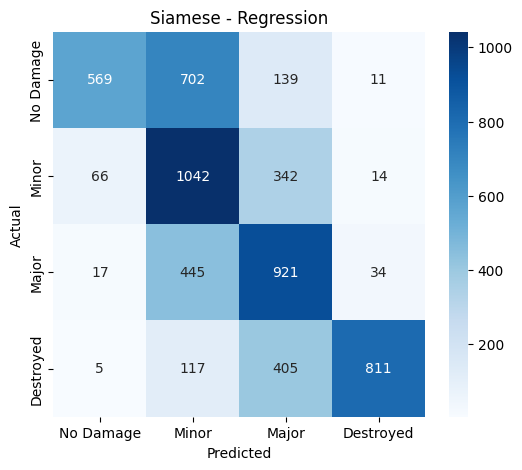

In [ ]:
metrics = evaluate_siamese(model, test_loader, device, mode=mode)

### DamageNet

#### Dataset

In [ ]:
transform = get_default_transforms()

train_loader, val_loader, test_loader = get_dataloaders("data", dataset_type="masks", transform=transform)

#### Classification

##### Training

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = DamageNet().to(device)

loss_fn = torch.nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

# Learning rate scheduler (optional)
scheduler = lr_scheduler.ReduceLROnPlateau(
            optimizer, factor=0.1, patience=10, min_lr=1e-5, verbose=True
        )

In [ ]:
train_logs, val_logs = train_damagenet_model(
    model, train_loader, val_loader, loss_fn, optimizer,  lr_scheduler=scheduler, epochs=10, device="cuda", start_save_epoch=10, save_path="/content/drive/MyDrive/thesis_code/classification/models"
)

Epoch 1/10


100%|██████████| 175/175 [00:21<00:00,  8.25it/s]


Epoch 1:
  Train Loss: 0.5307, Precision: 0.7916, Recall: 0.7895, F1: 0.7900, Accuracy: 0.7895
  Val Loss: 0.6156, Precision: 0.7552, Recall: 0.7553, F1: 0.7546, Accuracy: 0.7553
Epoch 2/10


100%|██████████| 175/175 [00:22<00:00,  7.72it/s]


Epoch 2:
  Train Loss: 0.5077, Precision: 0.7998, Recall: 0.7979, F1: 0.7984, Accuracy: 0.7979
  Val Loss: 0.6386, Precision: 0.7587, Recall: 0.7528, F1: 0.7527, Accuracy: 0.7528
Epoch 3/10


...

Epoch 8:
  Train Loss: 0.3077, Precision: 0.8798, Recall: 0.8795, F1: 0.8796, Accuracy: 0.8795
  Val Loss: 0.7917, Precision: 0.7345, Recall: 0.7378, F1: 0.7351, Accuracy: 0.7378
Epoch 9/10


100%|██████████| 175/175 [00:22<00:00,  7.73it/s]


Epoch 9:
  Train Loss: 0.2726, Precision: 0.8947, Recall: 0.8944, F1: 0.8945, Accuracy: 0.8944
  Val Loss: 0.8723, Precision: 0.7416, Recall: 0.7396, F1: 0.7392, Accuracy: 0.7396
Epoch 10/10


100%|██████████| 175/175 [00:22<00:00,  7.84it/s]


Epoch 10:
  Train Loss: 0.2374, Precision: 0.9098, Recall: 0.9097, F1: 0.9097, Accuracy: 0.9097
  Val Loss: 0.9568, Precision: 0.7379, Recall: 0.7281, F1: 0.7293, Accuracy: 0.7281


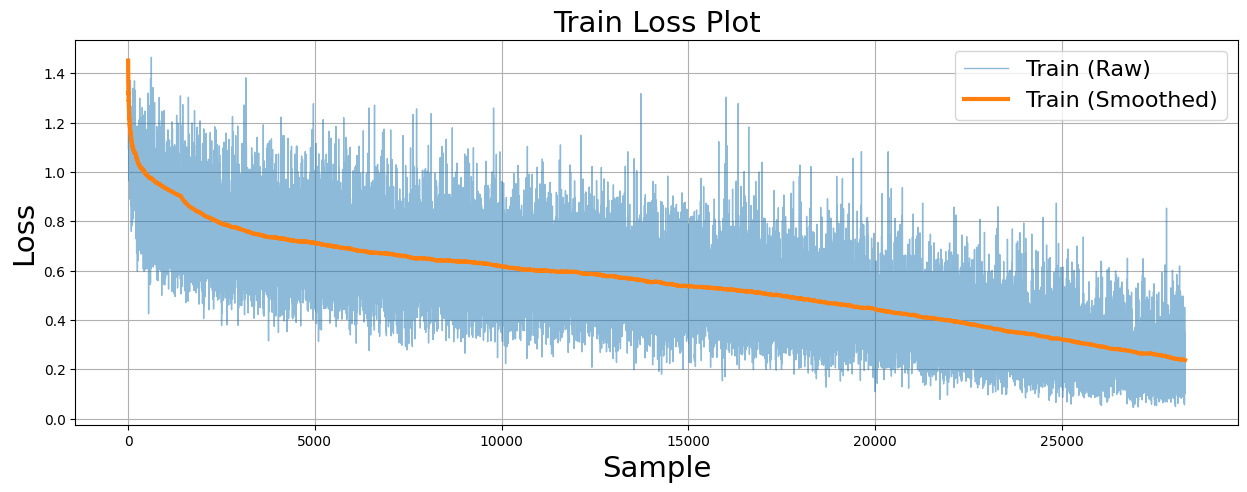

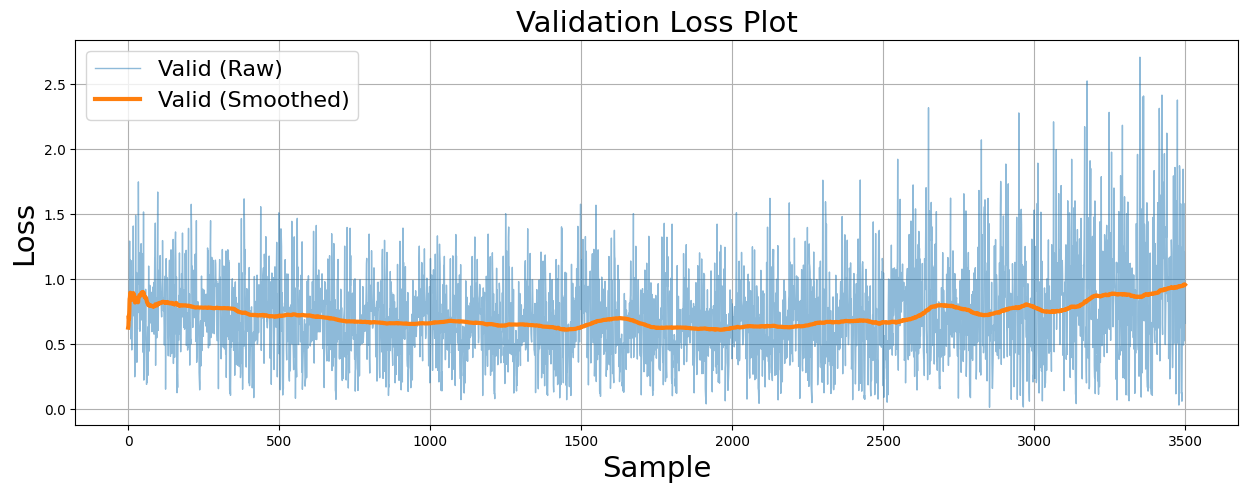

In [ ]:
train_series = pd.Series(train_logs)
val_series = pd.Series(val_logs)

# Compute rolling mean
train_smooth = train_series.rolling(window=1415, min_periods=1).mean()
val_smooth = val_series.rolling(window=175, min_periods=1).mean()

# Plot Train Loss
plt.figure(figsize=(15, 5))
plt.plot(train_logs, lw=1, alpha=0.5, label='Train (Raw)')
plt.plot(train_smooth, lw=3, label='Train (Smoothed)')
plt.xlabel('Sample', fontsize=21)
plt.ylabel('Loss', fontsize=21)
plt.title('Train Loss Plot', fontsize=21)
plt.legend(loc='best', fontsize=16)
plt.grid()
plt.show()

# Plot Validation Loss
plt.figure(figsize=(15, 5))
plt.plot(val_logs, lw=1, alpha=0.5, label='Valid (Raw)')
plt.plot(val_smooth, lw=3, label='Valid (Smoothed)')
plt.xlabel('Sample', fontsize=21)
plt.ylabel('Loss', fontsize=21)
plt.title('Validation Loss Plot', fontsize=21)
plt.legend(loc='best', fontsize=16)
plt.grid()
plt.show()

##### Evaluation

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = DamageNet().to(device)

checkpoint_path = "/content/drive/MyDrive/thesis_code/classification/models/model_DamageNet_10.pt"

# Load the checkpoint
checkpoint = torch.load(checkpoint_path, map_location=device)

# Restore the states
model.load_state_dict(checkpoint["model_state"])

<All keys matched successfully>

Evaluating DamageNet: 100%|██████████| 177/177 [00:21<00:00,  8.42it/s]



DamageNet Evaluation (Classification):
  Loss:      0.5965
  Accuracy:  0.7672
  Precision: 0.7668
  Recall:    0.7672
  F1 Score:  0.7664
  MSE:       0.5202
  MAE:       0.3163


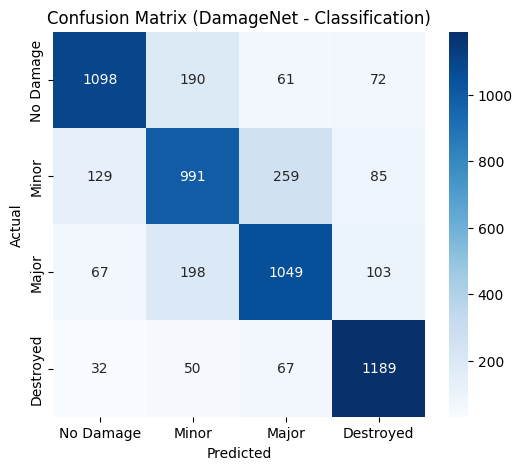

In [ ]:
metrics = evaluate_damagenet(model, test_loader, "cuda")

##### Building size influence

100%|██████████| 177/177 [00:20<00:00,  8.73it/s]
/content/drive/MyDrive/thesis_code/classification/scripts/evaluation.py:329: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=error_rates, x="size_group", y="error_rate", palette="viridis")


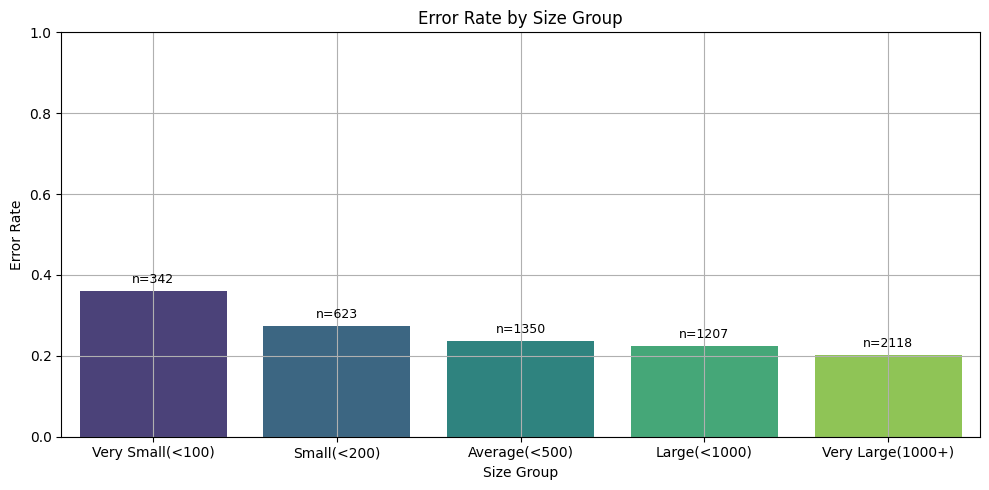

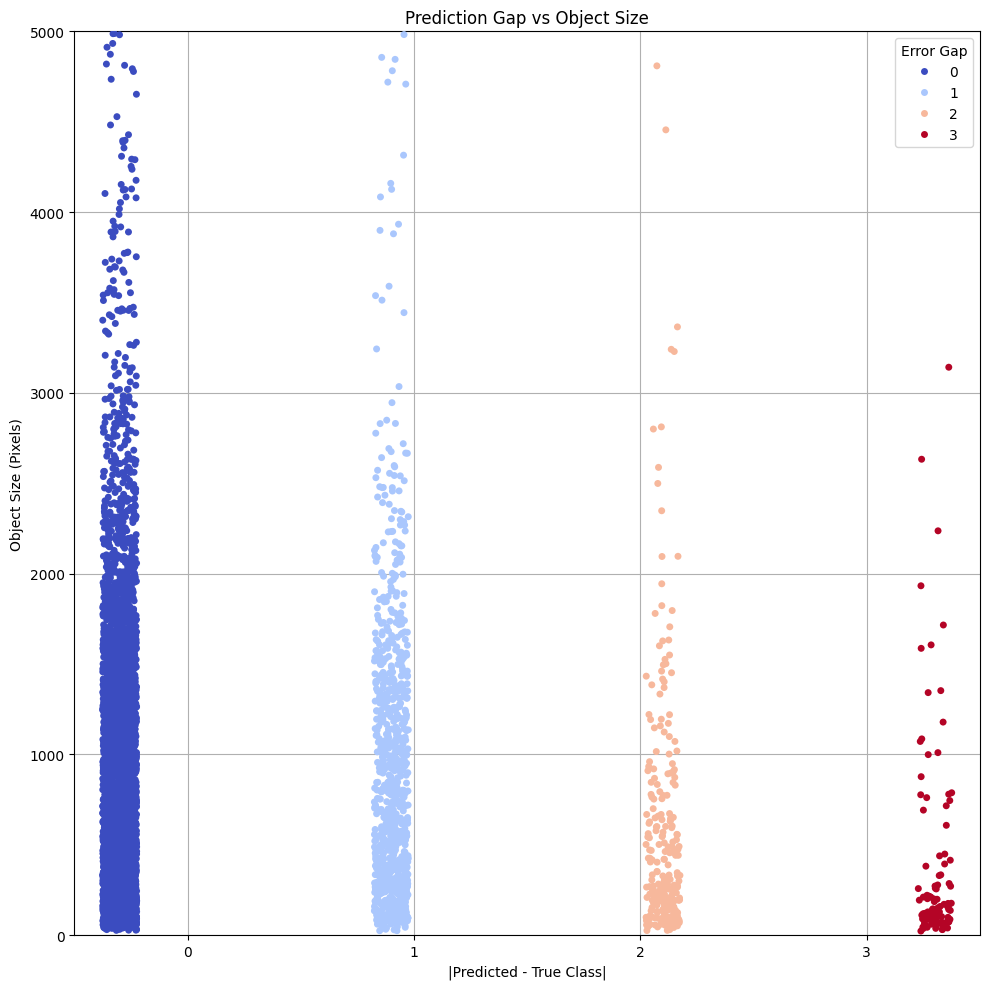

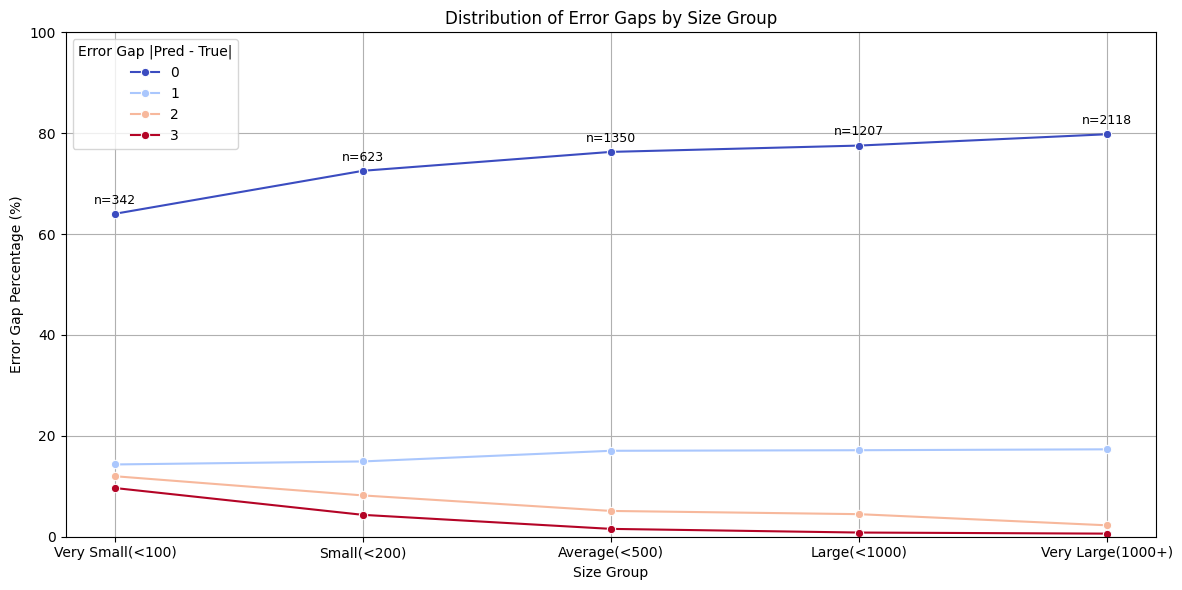

In [ ]:
transform = get_default_transforms()

_, _, test_loader_size = get_dataloaders("data", dataset_type="masks_size", transform=transform, test_only=True)

# Calling the functions with the model and test_loader
df = analyze_model_errors_by_size(model, test_loader_size, device)

plot_error_rate_by_size_group(df)
plot_error_gap_vs_size(df)
plot_error_gap_distribution_by_size_group(df)

#### Regression

##### Training

In [ ]:
from torch import optim
from torch.optim import lr_scheduler

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

mode = 'regression'

model = DamageNet(mode=mode).to(device)

loss_fn = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

# Learning rate scheduler (optional)
scheduler = lr_scheduler.ReduceLROnPlateau(
            optimizer, factor=0.1, patience=10, min_lr=1e-5, verbose=True
        )

/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


In [ ]:
train_logs, val_logs = train_damagenet_model(
    model, train_loader, val_loader, loss_fn, optimizer,  lr_scheduler=scheduler, epochs=15, device="cuda", mode=mode, start_save_epoch=15, save_path="/content/drive/MyDrive/thesis_code/classification/models"
)

Epoch 1/15


100%|██████████| 175/175 [00:21<00:00,  8.33it/s]


Epoch 1:
  Train Loss: 0.2557, Precision: 0.7795, Recall: 0.7551, F1: 0.7613, Accuracy: 0.7551
  Val Loss: 0.4253, Precision: 0.7222, Recall: 0.6879, F1: 0.6944, Accuracy: 0.6879
Epoch 2/15


100%|██████████| 175/175 [00:21<00:00,  8.25it/s]


Epoch 2:
  Train Loss: 0.2410, Precision: 0.7875, Recall: 0.7652, F1: 0.7710, Accuracy: 0.7652
  Val Loss: 0.4219, Precision: 0.7340, Recall: 0.6950, F1: 0.7022, Accuracy: 0.6950
Epoch 3/15


...

Epoch 13:
  Train Loss: 0.0585, Precision: 0.9374, Recall: 0.9371, F1: 0.9372, Accuracy: 0.9371
  Val Loss: 0.4147, Precision: 0.7212, Recall: 0.7024, F1: 0.7081, Accuracy: 0.7024
Epoch 14/15


100%|██████████| 175/175 [00:21<00:00,  8.20it/s]


Epoch 14:
  Train Loss: 0.0534, Precision: 0.9453, Recall: 0.9451, F1: 0.9452, Accuracy: 0.9451
  Val Loss: 0.4131, Precision: 0.7235, Recall: 0.7043, F1: 0.7101, Accuracy: 0.7043
Epoch 15/15


100%|██████████| 175/175 [00:21<00:00,  8.28it/s]


Epoch 15:
  Train Loss: 0.0492, Precision: 0.9541, Recall: 0.9539, F1: 0.9540, Accuracy: 0.9539
  Val Loss: 0.4173, Precision: 0.7180, Recall: 0.6940, F1: 0.7003, Accuracy: 0.6940


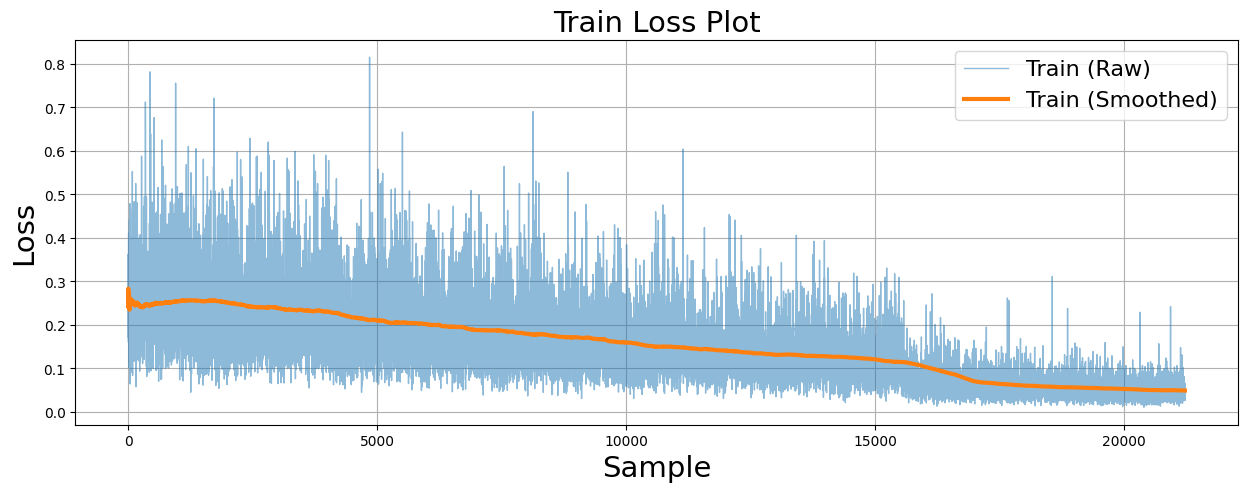

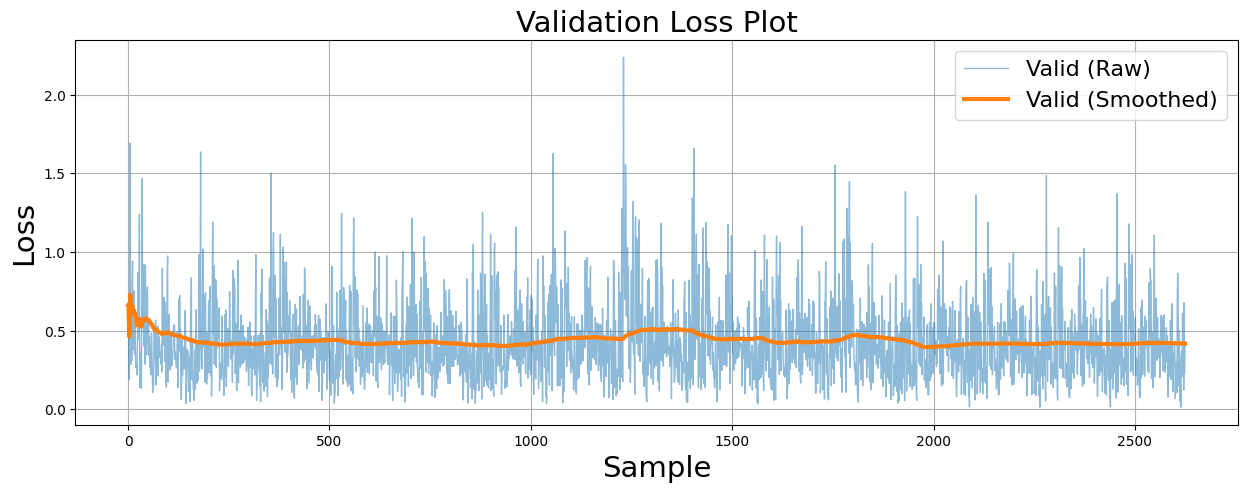

In [ ]:
train_series = pd.Series(train_logs)
val_series = pd.Series(val_logs)

# Compute rolling mean
train_smooth = train_series.rolling(window=1415, min_periods=1).mean()
val_smooth = val_series.rolling(window=175, min_periods=1).mean()

# Plot Train Loss
plt.figure(figsize=(15, 5))
plt.plot(train_logs, lw=1, alpha=0.5, label='Train (Raw)')
plt.plot(train_smooth, lw=3, label='Train (Smoothed)')
plt.xlabel('Sample', fontsize=21)
plt.ylabel('Loss', fontsize=21)
plt.title('Train Loss Plot', fontsize=21)
plt.legend(loc='best', fontsize=16)
plt.grid()
plt.show()

# Plot Validation Loss
plt.figure(figsize=(15, 5))
plt.plot(val_logs, lw=1, alpha=0.5, label='Valid (Raw)')
plt.plot(val_smooth, lw=3, label='Valid (Smoothed)')
plt.xlabel('Sample', fontsize=21)
plt.ylabel('Loss', fontsize=21)
plt.title('Validation Loss Plot', fontsize=21)
plt.legend(loc='best', fontsize=16)
plt.grid()
plt.show()

##### Evaluation

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

mode = 'regression'

model = DamageNet(mode=mode).to(device)

checkpoint_path = "/content/drive/MyDrive/thesis_code/classification/models/model_DamageNet_regression_15.pt"

# Load checkpoint
checkpoint = torch.load(checkpoint_path, map_location=device)

# Load model weights
model.load_state_dict(checkpoint["model_state"])

<All keys matched successfully>

Evaluating DamageNet: 100%|██████████| 177/177 [00:20<00:00,  8.46it/s]



DamageNet Evaluation (Regression):
  Loss:      0.3730
  Accuracy:  0.7073
  Precision: 0.7420
  Recall:    0.7073
  F1 Score:  0.7156
  MSE:       0.3745
  MAE:       0.4112


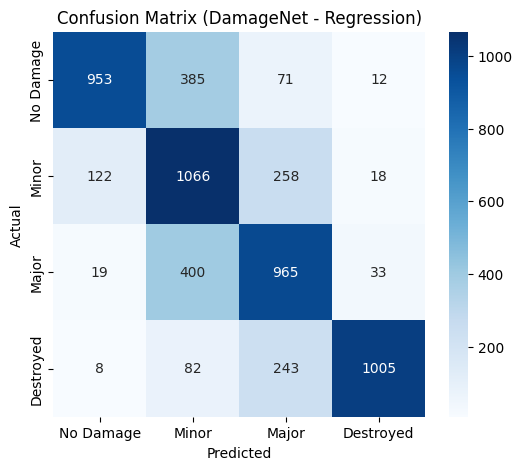

In [ ]:
metrics = evaluate_damagenet(model, test_loader, "cuda", mode=mode)

##### Building size influence

100%|██████████| 177/177 [00:20<00:00,  8.52it/s]
/content/drive/MyDrive/thesis_code/classification/scripts/evaluation.py:329: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=error_rates, x="size_group", y="error_rate", palette="viridis")


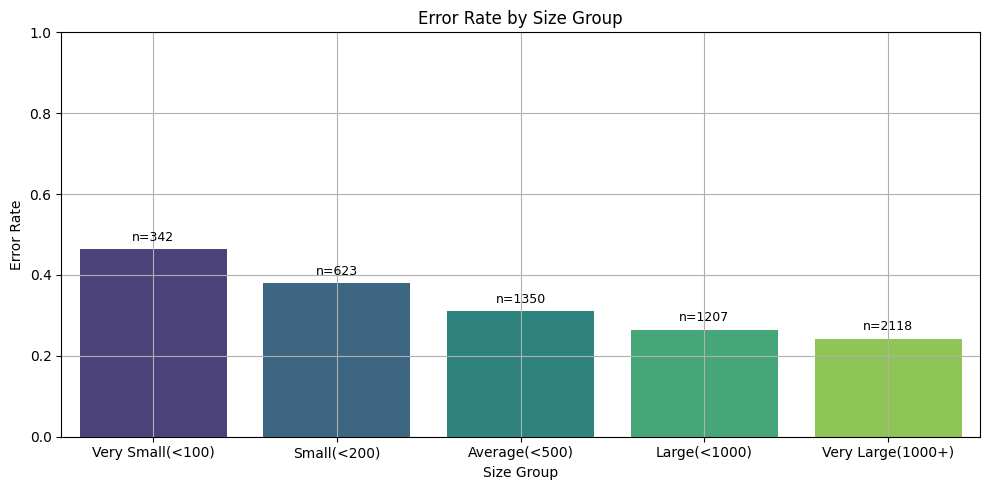

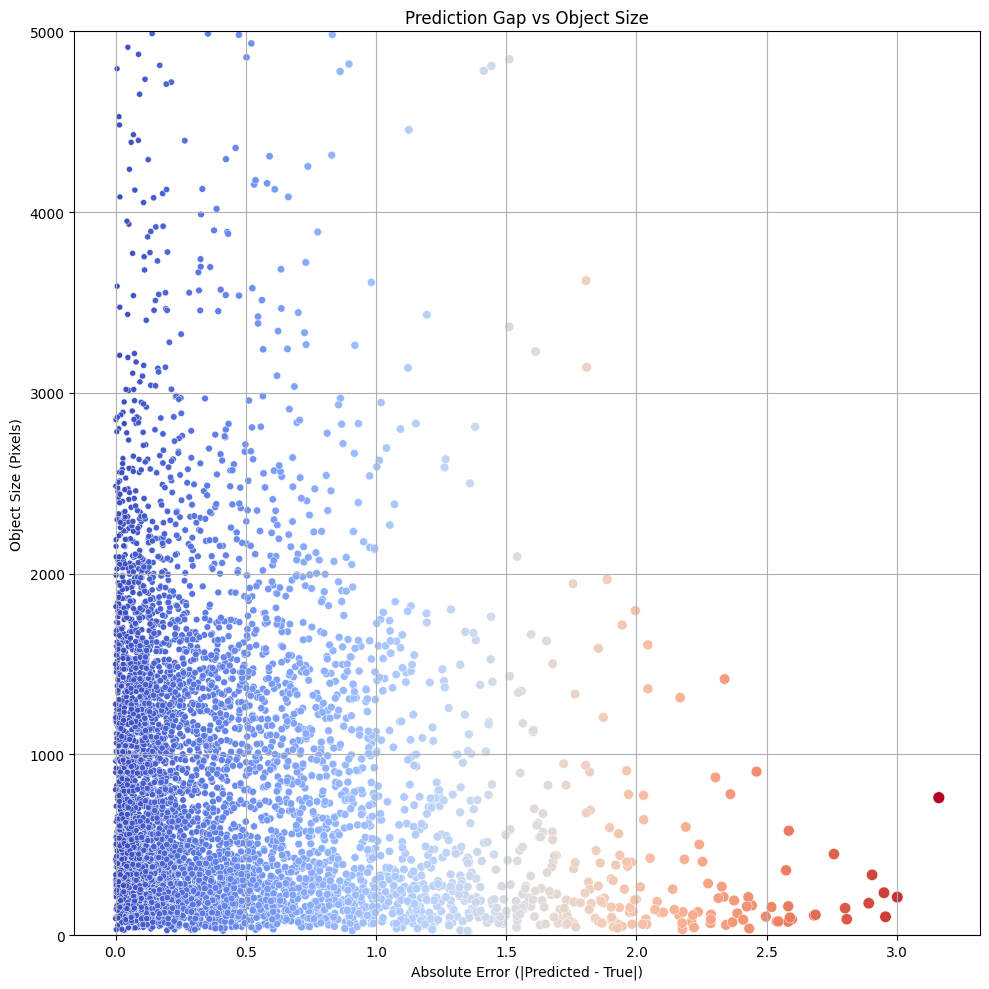

In [ ]:
transform = get_default_transforms()

_, _, test_loader_size = get_dataloaders("data", dataset_type="masks_size", transform=transform, test_only=True)

df = analyze_model_errors_by_size(model, test_loader_size, device, mode=mode)

plot_error_rate_by_size_group(df)
plot_error_gap_vs_size(df, mode=mode)